In [3]:
pip install pandas openpyxl matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_csv("c:\\Users\\Payal Jindal\\OneDrive\\Desktop\\projects\\powerbi\\online_retail_raw.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.isna().sum()) #only description has null values
print(df.duplicated().sum())
print(df.describe())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       

In [5]:
print("Unique invoices:", df["InvoiceNo"].nunique()) #25900
print("Unique customers:", df["CustomerID"].nunique()) #4372
print("Unique products:", df["StockCode"].nunique()) #4070

print("Negative quantities:", (df["Quantity"] < 0).sum()) #10624
print("Zero or negative prices:", (df["UnitPrice"] <= 0).sum()) #2517

print("First date:", df["InvoiceDate"].min()) #2010-12-01 08:26:00
print("Last date:", df["InvoiceDate"].max()) #2011-12-09 12:50:00

print(df["Country"].value_counts().head(10)) #top 10 country that orders

Unique invoices: 25900
Unique customers: 4372
Unique products: 4070
Negative quantities: 10624
Zero or negative prices: 2517
First date: 2010-12-01 08:26:00
Last date: 2011-12-09 12:50:00
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


In [6]:
#creating cancellation flag
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancellation"] = df["InvoiceNo"].str.startswith("C")

In [7]:
#standardize product descriptions:
df["Description"] = (
    df["Description"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [8]:
#Convert dates and customer IDs:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["CustomerID"] = (
    pd.to_numeric(df["CustomerID"], errors="coerce")
    .astype("Int64")
    .astype("string")
)

In [9]:
#remove exact duplicate rows:
df = df.drop_duplicates()

In [10]:
#remove unusable records:
df = df[df["InvoiceNo"].notna()]
df = df[df["StockCode"].notna()]
df = df[df["InvoiceDate"].notna()]

In [11]:
#create analytical columns
df["LineRevenue"] = df["Quantity"] * df["UnitPrice"]

df["OrderDate"] = df["InvoiceDate"].dt.date
df["Year"] = df["InvoiceDate"].dt.year
df["MonthNumber"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [12]:
#creating 2 datasets
all_transactions = df.copy() 
#keep purchases and cancellations for cancellation analysis

completed_sales = df[
    (~df["IsCancellation"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy() #Keep only valid positive sales for revenue and customer analysis

In [13]:
#exporting both:
all_transactions.to_csv(
    "all_transactions.csv",
    index=False
)

completed_sales.to_csv(
    "completed_sales.csv",
    index=False
)


In [14]:
#running data validation
print("CLEANED DATA VALIDATION")
print("-" * 35)

# 1. Dataset size
print("Rows:", len(completed_sales))
print("Columns:", completed_sales.shape[1])

# 2. Missing essential values
essential_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "InvoiceDate",
    "Quantity",
    "UnitPrice"
]

print("\nMissing essential values:")
print(completed_sales[essential_columns].isna().sum())

# 3. Duplicate rows
print(
    "\nExact duplicate rows:",
    completed_sales.duplicated().sum()
)

# 4. Invalid quantities and prices
print(
    "Quantity <= 0:",
    (completed_sales["Quantity"] <= 0).sum()
)

print(
    "UnitPrice <= 0:",
    (completed_sales["UnitPrice"] <= 0).sum()
)

# 5. Cancellations remaining
print(
    "Cancellation invoices remaining:",
    completed_sales["InvoiceNo"]
    .str.startswith("C")
    .sum()
)

# 6. Date range
print(
    "\nDate range:",
    completed_sales["InvoiceDate"].min(),
    "to",
    completed_sales["InvoiceDate"].max()
)

# 7. Revenue check
completed_sales["LineRevenue"] = (
    completed_sales["Quantity"] *
    completed_sales["UnitPrice"]
)

print(
    "Negative or zero revenue:",
    (completed_sales["LineRevenue"] <= 0).sum()
)

print(
    "Total revenue:",
    round(completed_sales["LineRevenue"].sum(), 2)
)

# 8. Key counts
print(
    "Unique orders:",
    completed_sales["InvoiceNo"].nunique()
)

print(
    "Unique products:",
    completed_sales["StockCode"].nunique()
)

print(
    "Unique identified customers:",
    completed_sales["CustomerID"].nunique()
)

# 9. Data types
print("\nData types:")
print(completed_sales.dtypes)


CLEANED DATA VALIDATION
-----------------------------------
Rows: 524878
Columns: 17

Missing essential values:
InvoiceNo      0
StockCode      0
Description    0
InvoiceDate    0
Quantity       0
UnitPrice      0
dtype: int64

Exact duplicate rows: 0
Quantity <= 0: 0
UnitPrice <= 0: 0
Cancellation invoices remaining: 0

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Negative or zero revenue: 0
Total revenue: 10642110.8
Unique orders: 19960
Unique products: 3922
Unique identified customers: 4338

Data types:
InvoiceNo                 object
StockCode                 object
Description       string[python]
Quantity                   int64
InvoiceDate       datetime64[ns]
UnitPrice                float64
CustomerID        string[python]
Country                   object
IsCancellation              bool
LineRevenue              float64
OrderDate                 object
Year                       int32
MonthNumber                int32
MonthName                 object
YearMonth       

In [15]:
#assertions for automated validation
assert completed_sales["InvoiceNo"].notna().all()
assert completed_sales["StockCode"].notna().all()
assert completed_sales["Description"].notna().all()
assert completed_sales["InvoiceDate"].notna().all()

assert (completed_sales["Quantity"] > 0).all()
assert (completed_sales["UnitPrice"] > 0).all()
assert (completed_sales["LineRevenue"] > 0).all()

assert not completed_sales["InvoiceNo"].str.startswith("C").any()
assert completed_sales.duplicated().sum() == 0

print("All validation checks passed.")

All validation checks passed.


In [16]:
customer_sales = completed_sales[
    completed_sales["CustomerID"].notna()
].copy()

print("Completed-sales rows:", len(completed_sales))
print("Customer-sales rows:", len(customer_sales))
print(
    "Rows excluded due to missing CustomerID:",
    len(completed_sales) - len(customer_sales)
)

Completed-sales rows: 524878
Customer-sales rows: 392692
Rows excluded due to missing CustomerID: 132186


In [17]:
#comparing the rows before and after cleaning
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original data",
        "After duplicate removal",
        "Completed sales",
        "Customer-level sales"
    ],
    "Rows": [
        541909,
        len(df),
        len(completed_sales),
        len(customer_sales)
        
    ]
})

cleaning_summary

,Stage,Rows
0,Original data,541909
1,After duplicate removal,536641
2,Completed sales,524878
3,Customer-level sales,392692


In [18]:
#overall business kpi
total_revenue = completed_sales["LineRevenue"].sum()
total_orders = completed_sales["InvoiceNo"].nunique()
total_customers = customer_sales["CustomerID"].nunique()
units_sold = completed_sales["Quantity"].sum()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Identified Customers: {total_customers:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Identified Customers: 4,338
Units Sold: 5,572,420
Average Order Value: £533.17


<Axes: title={'center': 'Monthly Revenue'}, xlabel='YearMonth'>

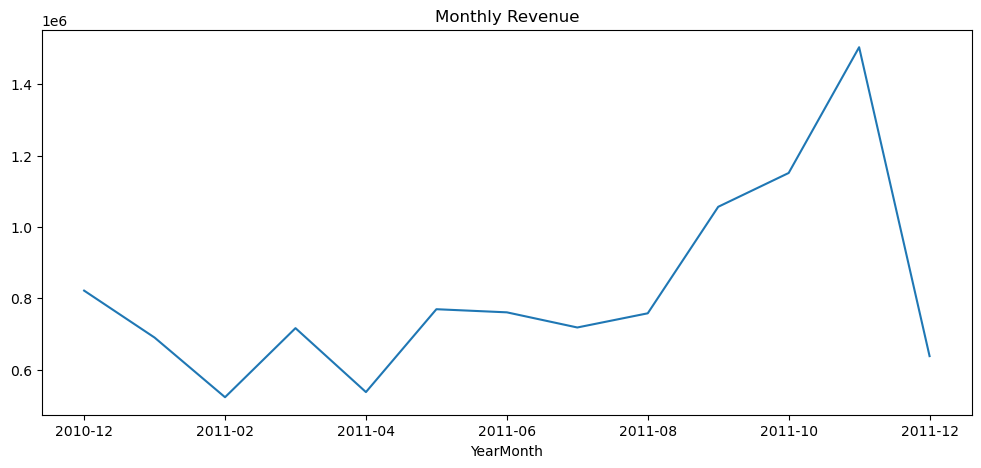

In [19]:
#EDA###
#revenue over time
monthly_revenue = (
    completed_sales
    .groupby("YearMonth")["LineRevenue"]
    .sum()
)

monthly_revenue.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue"
)


<Axes: title={'center': 'Top 10 Countries by Revenue'}, ylabel='Country'>

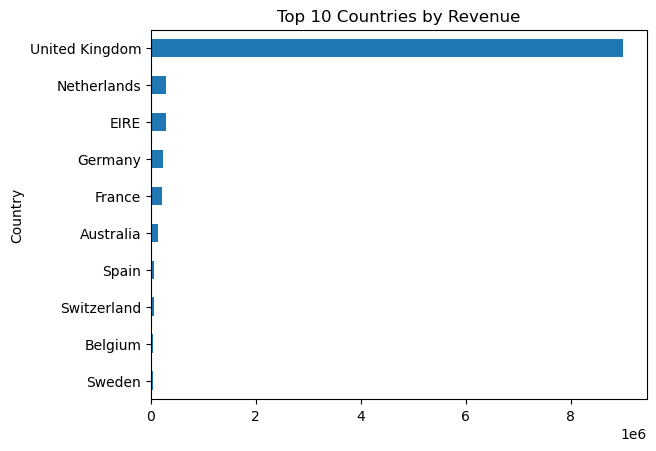

In [20]:
#revenue by country
country_revenue = (
    completed_sales
    .groupby("Country")["LineRevenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue.sort_values().plot(
    kind="barh",
    title="Top 10 Countries by Revenue"
)

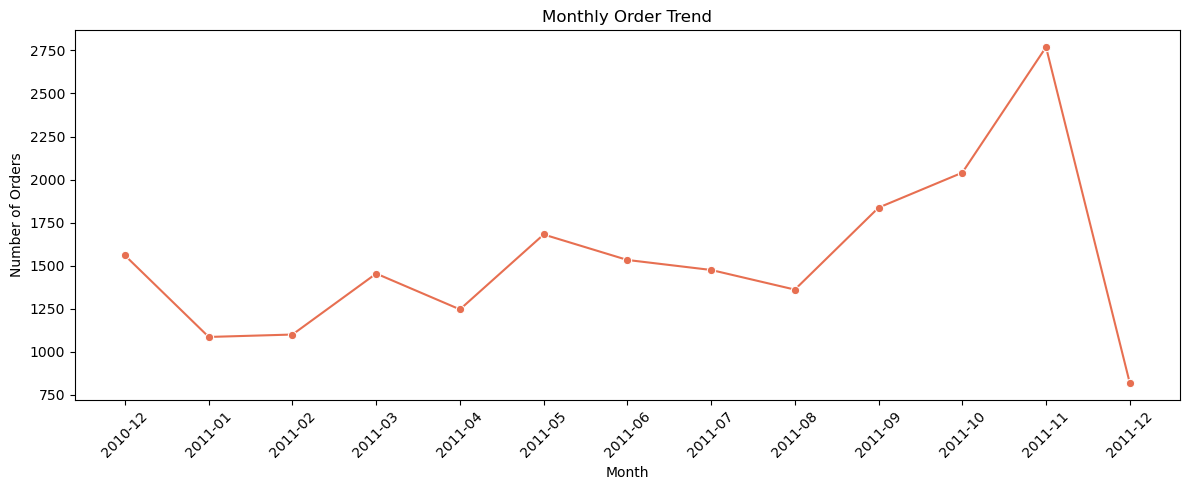

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#monthly order trend

monthly_orders = (
    completed_sales
    .groupby("YearMonth", as_index=False)
    .agg(Orders=("InvoiceNo", "nunique"))
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="YearMonth",
    y="Orders",
    marker="o",
    color="#E76F51"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

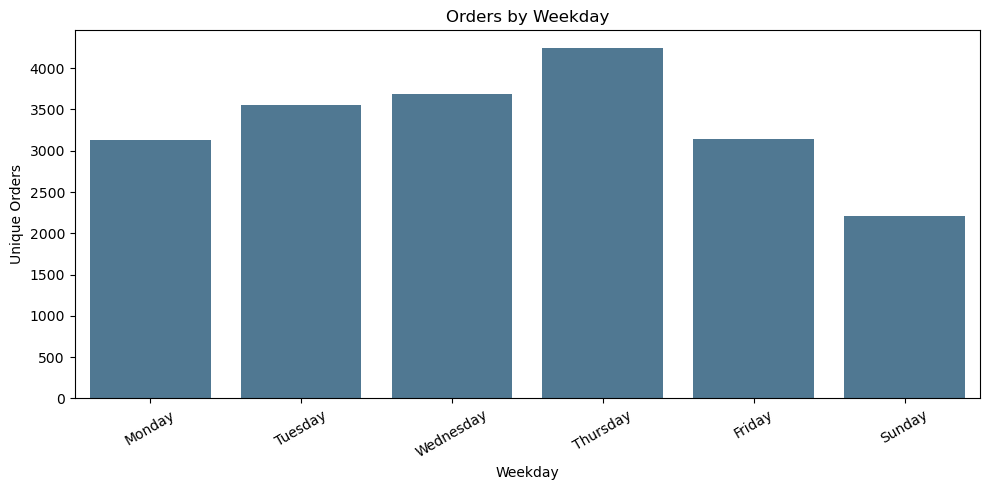

In [22]:
#orders by weekday
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

completed_sales["Weekday"] = (
    completed_sales["InvoiceDate"].dt.day_name()
)

orders_by_weekday = (
    completed_sales
    .groupby("Weekday")["InvoiceNo"]
    .nunique()
    .reindex(weekday_order)
    .dropna()
    .reset_index(name="Orders")
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=orders_by_weekday,
    x="Weekday",
    y="Orders",
    color="#457B9D"
)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Unique Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

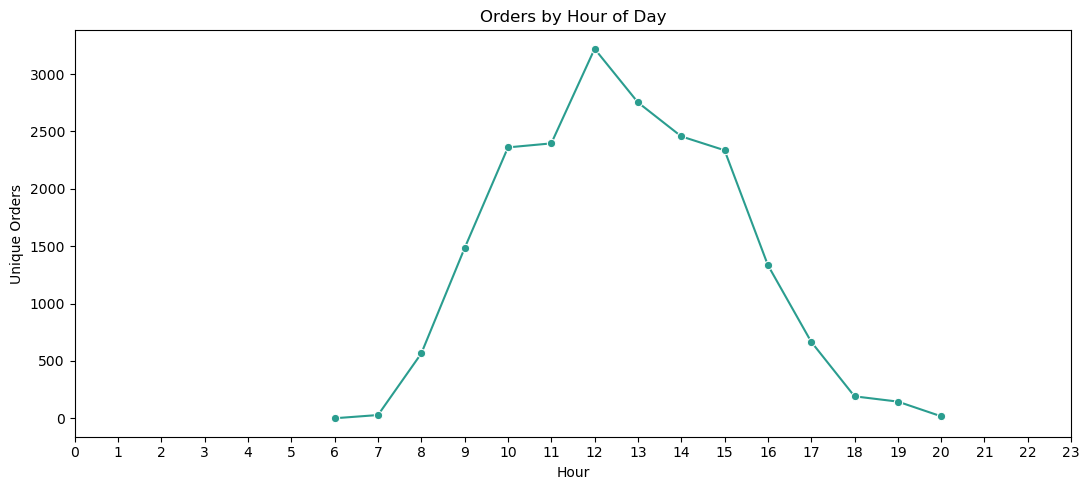

In [23]:
#orders by hour
completed_sales["Hour"] = (
    completed_sales["InvoiceDate"].dt.hour
)

orders_by_hour = (
    completed_sales
    .groupby("Hour", as_index=False)
    .agg(Orders=("InvoiceNo", "nunique"))
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=orders_by_hour,
    x="Hour",
    y="Orders",
    marker="o",
    color="#2A9D8F"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Unique Orders")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

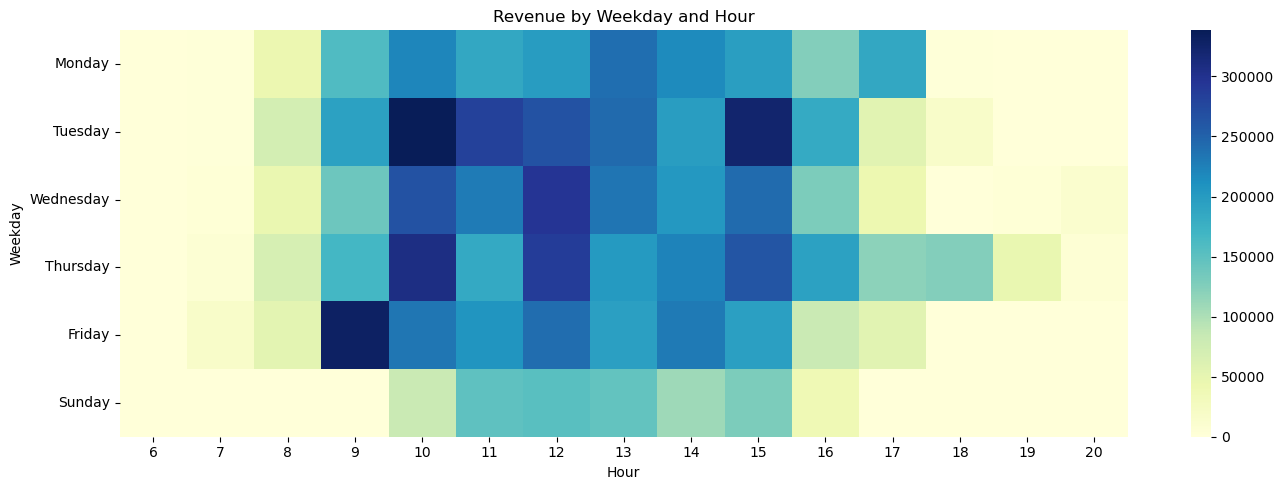

In [24]:
#revenue heatmap by weekday and hour
revenue_heatmap = completed_sales.pivot_table(
    index="Weekday",
    columns="Hour",
    values="LineRevenue",
    aggfunc="sum",
    fill_value=0
)

available_weekdays = [
    day for day in weekday_order
    if day in revenue_heatmap.index
]

revenue_heatmap = revenue_heatmap.reindex(available_weekdays)

plt.figure(figsize=(14, 5))

sns.heatmap(
    revenue_heatmap,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Revenue by Weekday and Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

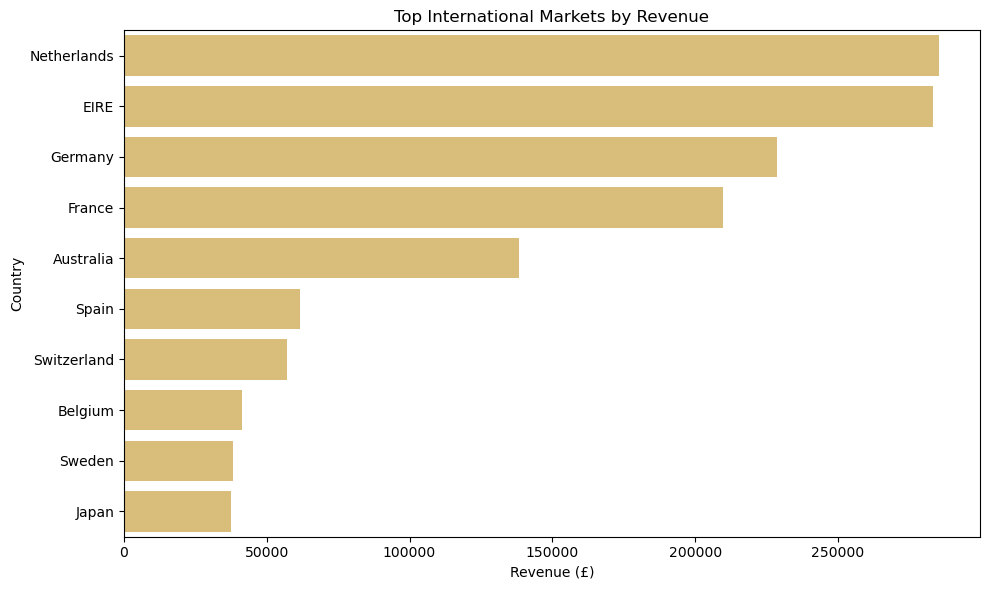

In [25]:
#top 10 countries excluding UK
international_sales = completed_sales[
    completed_sales["Country"] != "United Kingdom"
].copy()

international_country_revenue = (
    international_sales
    .groupby("Country", as_index=False)
    .agg(Revenue=("LineRevenue", "sum"))
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=international_country_revenue,
    x="Revenue",
    y="Country",
    color="#E9C46A"
)

plt.title("Top International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

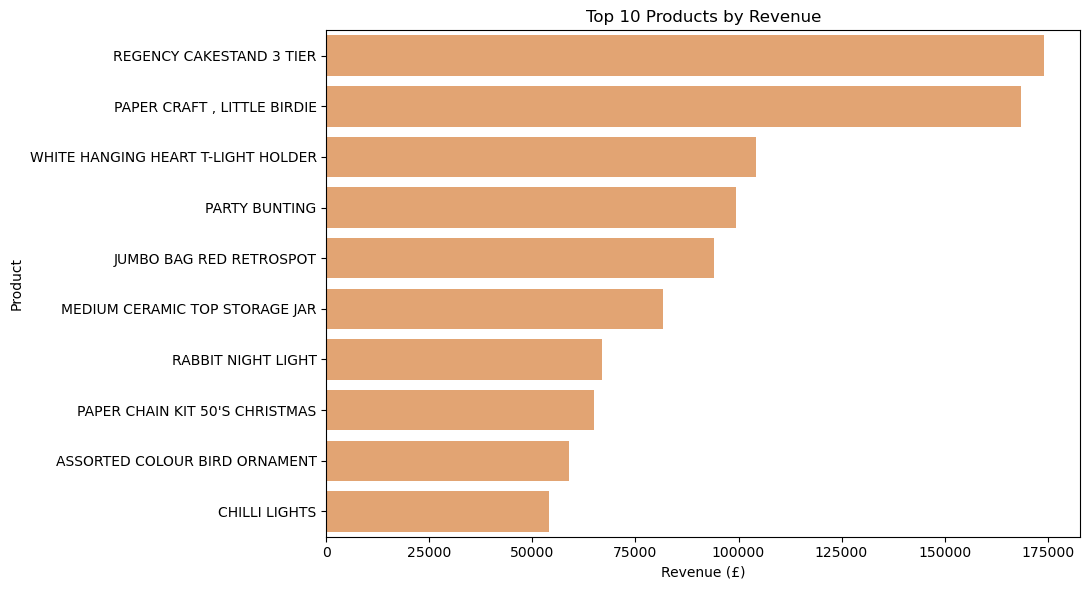

In [26]:
#top products by revenue
non_product_codes = [
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "C2",
    "AMAZONFEE"
]

product_sales = completed_sales[
    ~completed_sales["StockCode"].isin(non_product_codes)
].copy()

top_products_revenue = (
    product_sales
    .groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        Revenue=("LineRevenue", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description",
    color="#F4A261"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

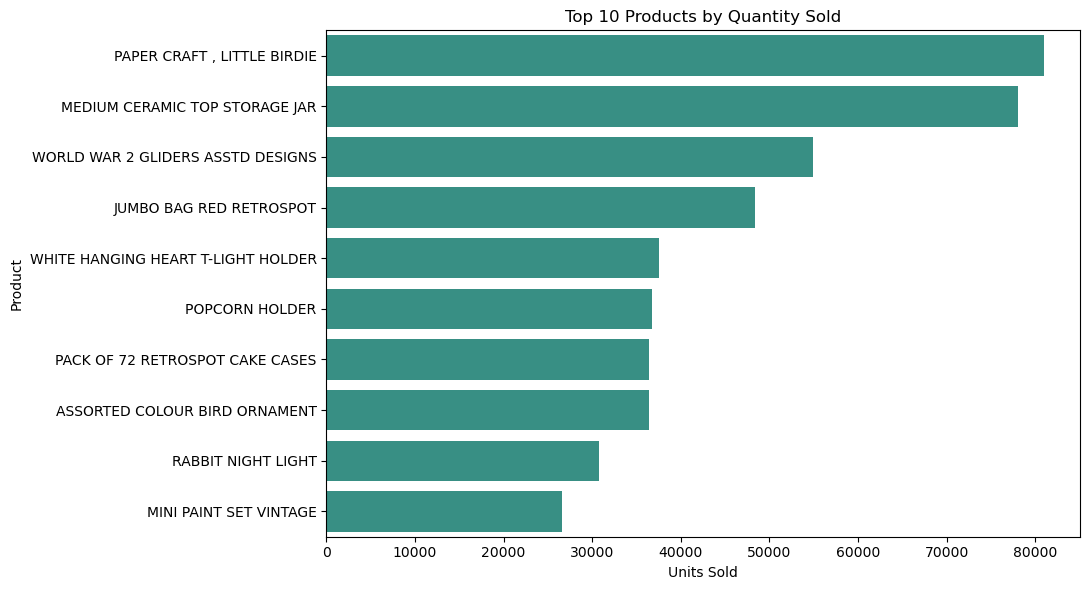

In [27]:
#top products by quantity sold
top_products_quantity = (
    product_sales
    .groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        QuantitySold=("Quantity", "sum"),
        Revenue=("LineRevenue", "sum")
    )
    .sort_values("QuantitySold", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_products_quantity,
    x="QuantitySold",
    y="Description",
    color="#2A9D8F"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [28]:
#cancellation analysis
invoice_status = (
    df.groupby("InvoiceNo", as_index=False)
    .agg(IsCancellation=("IsCancellation", "max"))
)

total_invoices = invoice_status["InvoiceNo"].nunique()
cancelled_invoices = invoice_status["IsCancellation"].sum()

cancellation_rate = (
    cancelled_invoices / total_invoices * 100
)

print(f"Total invoices: {total_invoices:,}")
print(f"Cancelled invoices: {cancelled_invoices:,}")
print(f"Invoice cancellation rate: {cancellation_rate:.2f}%")

Total invoices: 25,900
Cancelled invoices: 3,836
Invoice cancellation rate: 14.81%


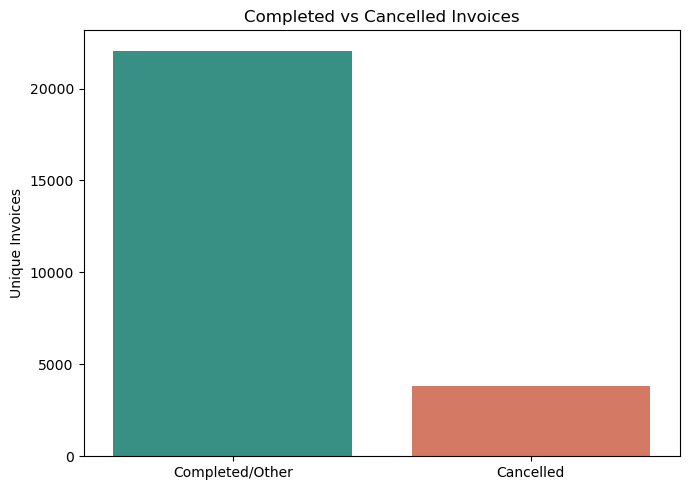

In [29]:
cancellation_summary = pd.DataFrame({
    "Status": ["Completed/Other", "Cancelled"],
    "Invoices": [
        total_invoices - cancelled_invoices,
        cancelled_invoices
    ]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=cancellation_summary,
    x="Status",
    y="Invoices",
    hue="Status",
    palette=["#2A9D8F", "#E76F51"],
    legend=False
)

plt.title("Completed vs Cancelled Invoices")
plt.xlabel("")
plt.ylabel("Unique Invoices")
plt.tight_layout()
plt.show()

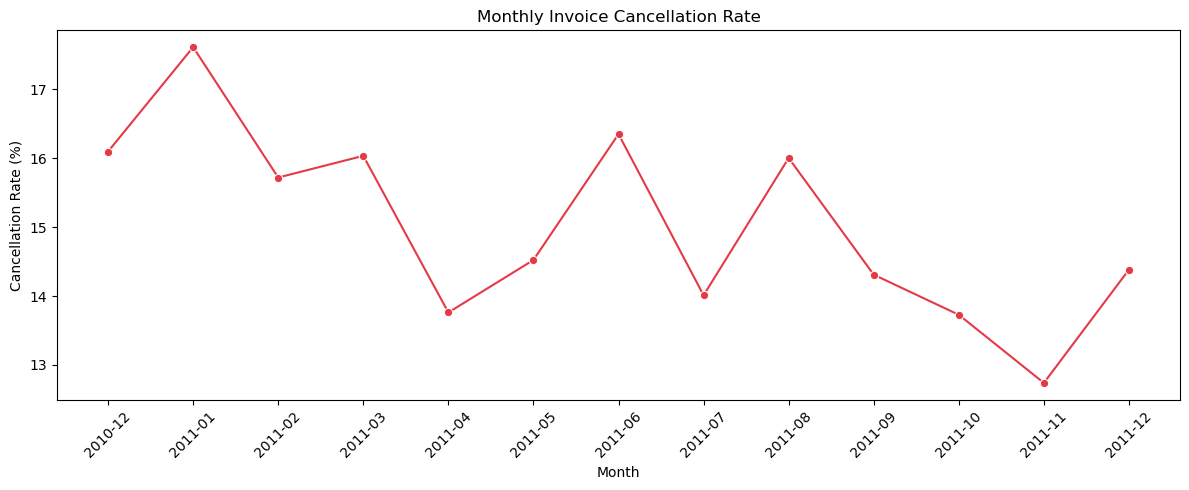

In [30]:
#monthly cancellation trend
invoice_monthly_status = (
    df.groupby("InvoiceNo", as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        IsCancellation=("IsCancellation", "max")
    )
)

invoice_monthly_status["YearMonth"] = (
    invoice_monthly_status["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

monthly_cancellations = (
    invoice_monthly_status
    .groupby("YearMonth", as_index=False)
    .agg(
        TotalInvoices=("InvoiceNo", "nunique"),
        CancelledInvoices=("IsCancellation", "sum")
    )
)

monthly_cancellations["CancellationRate"] = (
    monthly_cancellations["CancelledInvoices"] /
    monthly_cancellations["TotalInvoices"] *
    100
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_cancellations,
    x="YearMonth",
    y="CancellationRate",
    marker="o",
    color="#E63946"
)

plt.title("Monthly Invoice Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#repeat customer rate
customer_order_counts = (
    customer_sales
    .groupby("CustomerID", as_index=False)
    .agg(OrderCount=("InvoiceNo", "nunique"))
)

customer_order_counts["CustomerType"] = np.where(
    customer_order_counts["OrderCount"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_type_summary = (
    customer_order_counts["CustomerType"]
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = [
    "CustomerType",
    "Customers"
]

repeat_customer_rate = (
    (
        customer_order_counts["OrderCount"] > 1
    ).mean() * 100
)

print(f"Repeat-customer rate: {repeat_customer_rate:.2f}%")

Repeat-customer rate: 65.58%


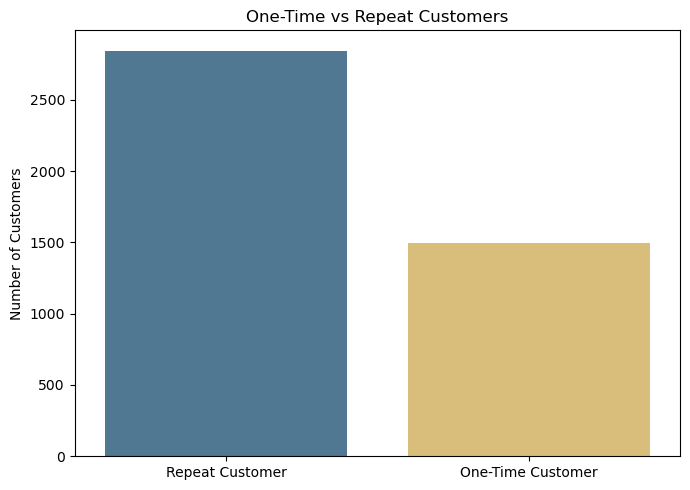

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=customer_type_summary,
    x="CustomerType",
    y="Customers",
    hue="CustomerType",
    palette=["#457B9D", "#E9C46A"],
    legend=False
)

plt.title("One-Time vs Repeat Customers")
plt.xlabel("")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [33]:
#rfm eda : rfm customer metrics 
reference_date = (
    customer_sales["InvoiceDate"].max() +
    pd.Timedelta(days=1)
)

rfm = (
    customer_sales
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineRevenue", "sum")
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


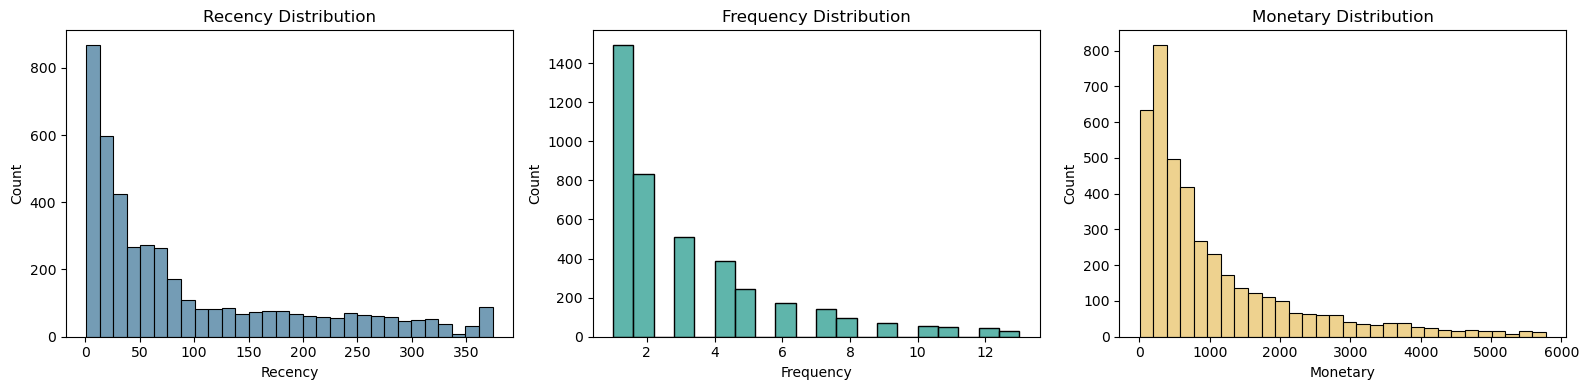

In [34]:
#rfm distribution plots
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

sns.histplot(
    data=rfm,
    x="Recency",
    bins=30,
    ax=axes[0],
    color="#457B9D"
)

axes[0].set_title("Recency Distribution")

frequency_limit = rfm["Frequency"].quantile(0.95)

sns.histplot(
    data=rfm[rfm["Frequency"] <= frequency_limit],
    x="Frequency",
    bins=20,
    ax=axes[1],
    color="#2A9D8F"
)

axes[1].set_title("Frequency Distribution")

monetary_limit = rfm["Monetary"].quantile(0.95)

sns.histplot(
    data=rfm[rfm["Monetary"] <= monetary_limit],
    x="Monetary",
    bins=30,
    ax=axes[2],
    color="#E9C46A"
)

axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [35]:
#revenue conc among customers
customer_revenue = (
    customer_sales
    .groupby("CustomerID")["LineRevenue"]
    .sum()
    .sort_values(ascending=False)
)

top_10_percent_count = max(
    1,
    int(len(customer_revenue) * 0.10)
)

top_10_percent_revenue = (
    customer_revenue.head(top_10_percent_count).sum()
)

revenue_contribution = (
    top_10_percent_revenue /
    customer_revenue.sum() *
    100
)

print(
    "Revenue contributed by top 10% of identified customers:",
    f"{revenue_contribution:.2f}%"
)

customer_sales.to_csv(
    "customer_sales.csv",
    index=False
)

Revenue contributed by top 10% of identified customers: 61.41%


In [36]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Completed Sales Rows",
        "Total Revenue",
        "Unique Orders",
        "Identified Customers",
        "Units Sold",
        "Average Order Value",
        "Cancellation Rate",
        "Repeat Customer Rate"
    ],
    "Value": [
        f"{len(completed_sales):,}",
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{units_sold:,}",
        f"£{average_order_value:,.2f}",
        f"{cancellation_rate:.2f}%",
        f"{repeat_customer_rate:.2f}%"
    ]
})

eda_summary

,Metric,Value
0,Completed Sales Rows,"524,878"
1,Total Revenue,"£10,642,110.80"
2,Unique Orders,"19,960"
3,Identified Customers,"4,338"
4,Units Sold,"5,572,420"
5,Average Order Value,£533.17
6,Cancellation Rate,14.81%
7,Repeat Customer Rate,65.58%


In [40]:
customer_sales.to_csv(
    "customer_sales.csv",
    index=False
)

In [46]:
completed_sales = completed_sales.rename(columns={
    "Year": "YearNumber",
    "Weekday": "WeekdayName",
    "Hour": "HourNumber",
    "Description": "ProductDescription",
    "MonthName": "MonthLabel"
})
completed_sales = completed_sales.drop(
    columns=["IsCancellation"],
    errors="ignore"
)

print(completed_sales.columns.tolist())



completed_sales.to_csv(
    "completed_sales_sqlserver.csv",
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d %H:%M:%S",
    lineterminator="\n"
)

print(completed_sales.shape)

['InvoiceNo', 'StockCode', 'ProductDescription', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'LineRevenue', 'OrderDate', 'YearNumber', 'MonthNumber', 'MonthLabel', 'YearMonth', 'WeekdayName', 'HourNumber']
(524878, 16)


In [45]:
print(
    "Missing InvoiceNo:",
    completed_sales["InvoiceNo"].isna().sum()
)

print(
    "Blank InvoiceNo:",
    completed_sales["InvoiceNo"]
    .astype("string")
    .str.strip()
    .eq("")
    .sum()
)

Missing InvoiceNo: 0
Blank InvoiceNo: 0


In [47]:
print(len(completed_sales))

524878
